(-1.0, 2.0)

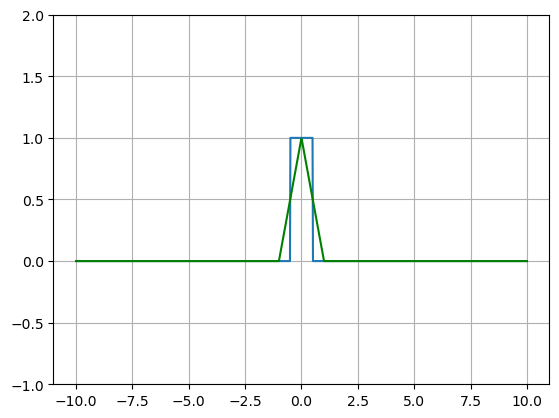

In [22]:
%matplotlib inline
import numpy as np
import matplotlib.pylab as plt

def Square(t, w):
    # if t smaller than a half period -> 1
    # if t greater or equal than half a period -> 0
    T = 1/w
    return 1 if (t%T) < (T/2) else 0

def Sinc(t, w):
  return np.sin(w*t) / (w*t)

def Rect(t, T):
  return 1 if abs(t) < (T/2) else 0

def Convolve(f, g, w_f, w_g, t, N=50, dN=0.01):
  x = 0
  ks = np.linspace(-N/2,N/2,int(N/dN))
  for k in ks:
    x += f(k, w_f)*g(t-k, w_g)*dN   # h(n) = sum_k f(n-k)g(k)
  return x

x = np.linspace(-10,10, 1000)

plt.plot(x, [Rect(t, 1) for t in x]) # freq = 1kHz, period = 1ms
plt.grid()
y = np.zeros(len(x))
for i in range(len(x)):
  y[i] = Convolve(Rect, Rect, 1, 1, x[i])
#y <- Convolve(Rect, Rect, 1, 1, x)
plt.plot(x, y, color='green')
plt.ylim(-1,2)

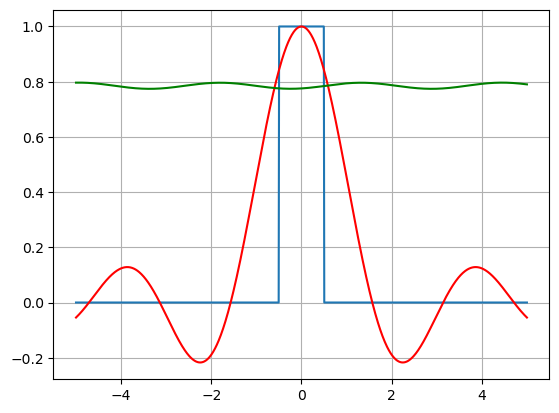

In [25]:
x = np.linspace(-5,5, 1000)
#plt.plot(x, [Square(t, 1) for t in x]) # freq = 1kHz, period = 1ms
plt.plot(x, [Rect(t, 1) for t in x]) # freq = 1kHz, period = 1ms
plt.grid()
w = 2                          # 2kHz
plt.plot(x, Sinc(x, w), color='red')
plt.plot(x, Convolve(Square, Sinc, 1, 2, x), color='green')

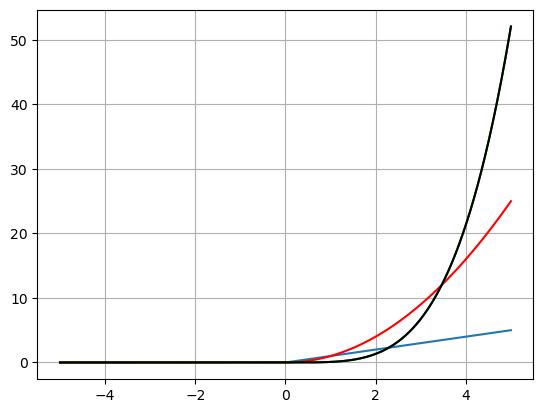

In [34]:
def u(t):
  return 1 if t > 0 else 0

def f(t):
    return t*u(t)

def g(t):
    return t**2*u(t)

def Convolve(f, g, t, N=50, dN=0.01):
  x = 0
  ks = np.linspace(-N/2,N/2,int(N/dN))
  for k in ks:
    x += f(k)*g(t-k)*dN   # h(n) = sum_k f(n-k)g(k)
  return x
    
x = np.linspace(-5,5, 1000)
plt.plot(x, [f(t) for t in x]) 
plt.plot(x, [g(t) for t in x], color='red') 
plt.grid()
plt.plot(x, [Convolve(f, g, t) for t in x], color='green')
plt.plot(x, [t**4/12*u(t) for t in x], color='k')